# Tutorial 04 — Representation Learning, Embeddings and Self-Supervision

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **Can we learn useful representations without knowing the final task?**

---

## 1. Why this matters

This is the hinge of the course. Everything in tutorials 01–03 started from a
task: *predict the load at t+24*. Features, architecture and loss were all
chosen to serve that task, and the resulting model is worth nothing for any
other question.

Here we do something that should feel strange the first time: we train a model
with **no labels and no task**, purely to compress and reconstruct the data.
Then we discover that the internal representation it built is useful for a
task it was never shown — and useful *with very few labels*.

That is the entire mechanism behind foundation models. Tutorial 09 will show
it at the scale of a 120-million-parameter pretrained forecaster and tutorial
10 across electrical grids; this notebook shows it at a scale you can train in
thirty seconds and inspect completely.

## 2. Historical context

Autoencoders are old (Hinton & Salakhutdinov, 2006, used them to make deep
nets trainable at all). The idea became central in 2013 with Word2Vec, which
showed that a representation learned from a throwaway prediction task — guess
the neighbouring word — had genuine semantic geometry. Then came contrastive
methods (SimCLR, 2020), masked modelling in text (BERT, 2018) and in images
(MAE, 2021). By 2024 the same recipe was being applied to protein sequences,
weather states and electricity time series.

The name changed — "unsupervised", then "self-supervised" — but the move is
always the same: **manufacture a supervised problem out of the data's own
structure, so that solving it requires understanding the data.**

## 3. Learning objectives

By the end of this notebook you can:

- explain latent space, embedding and representation, and use the words
  precisely;
- implement an autoencoder and a *masked* autoencoder on power-system profiles;
- explain the Word2Vec intuition and find nearest neighbours in an embedding
  space you trained yourself;
- explain contrastive learning and why the choice of augmentation is the
  scientific content of the method;
- run a **label-efficiency experiment** — the single most important experiment
  in this course — and read the result correctly;
- state when pretraining does *not* pay for itself.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.manifold import TSNE
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import mae, point_metrics, r2
from ai_power_course.models.representation import (
    MaskedProfileAutoencoder,
    ProfileEncoder,
    block_mask,
    masked_reconstruction_loss,
    nt_xent_loss,
    random_mask,
)
from ai_power_course.models.training import TrainConfig, count_parameters, make_loader, train_model
from ai_power_course.plotting import COLORS, plot_embedding, use_course_style

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. Theory

### Representation, latent space, embedding

A **representation** is whatever internal vector a model computes before its
final layer. The space those vectors live in is the **latent space**, and one
particular vector is an **embedding** of its input. The words are close to
interchangeable; what matters is the property we want:

> Inputs that are *similar in a way we care about* should be close together,
> and the useful factors of variation should be easy to read off — ideally
> with a linear map.

### Three ways to get one without labels

| objective | training signal | canonical example |
|---|---|---|
| **reconstruct** | rebuild the input from a bottleneck | autoencoder |
| **mask and predict** | rebuild a hidden part from the rest | BERT, MAE, Chronos |
| **contrast** | two views of one thing should agree | Word2Vec, SimCLR, CLIP |

A plain autoencoder has a known weakness: with a wide enough bottleneck it can
approximate the identity function and learn nothing abstract. Masking removes
that escape route — you cannot copy what you cannot see.

### Pretraining versus downstream training

$$\underbrace{\text{encoder } f_\theta}_{\text{pretrained once, no labels}}
  \;\longrightarrow\;
  \underbrace{\text{head } g_\phi}_{\text{trained per task, few labels}}$$

After pretraining, $f_\theta$ is the asset. The head is disposable.

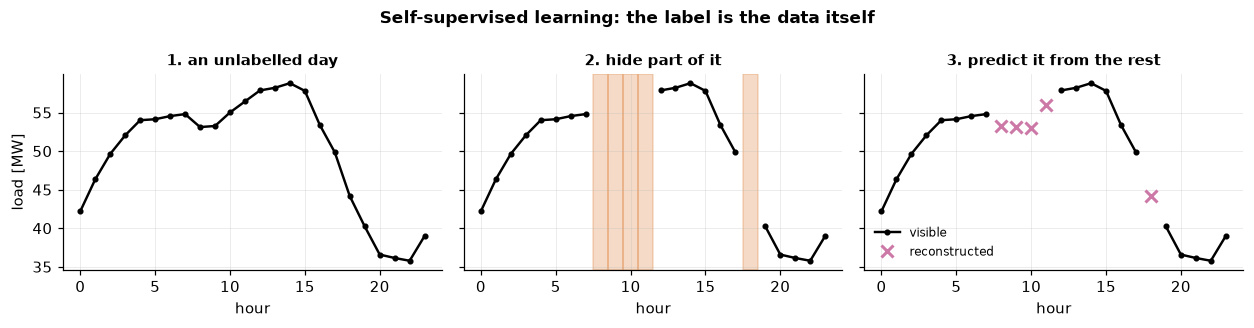

In [2]:
fig = diagrams.self_supervised_masking()
plt.show()

## 5. The data: one day at a time

We reshape the hourly series into **daily profiles** of 24 values and
normalise each day to zero mean and unit variance. That normalisation is a
modelling decision with consequences: it throws away the absolute level and
keeps only the *shape* of the day. We want shape, because shape is what
transfers between a 50 MW feeder and a 50 GW system.

pretraining profiles : (730, 24, 1)  (2017-01-01 to 2018-12-31)
validation profiles  : (365, 24, 1)
test profiles        : (366, 24, 1)

No labels anywhere. These are just days.


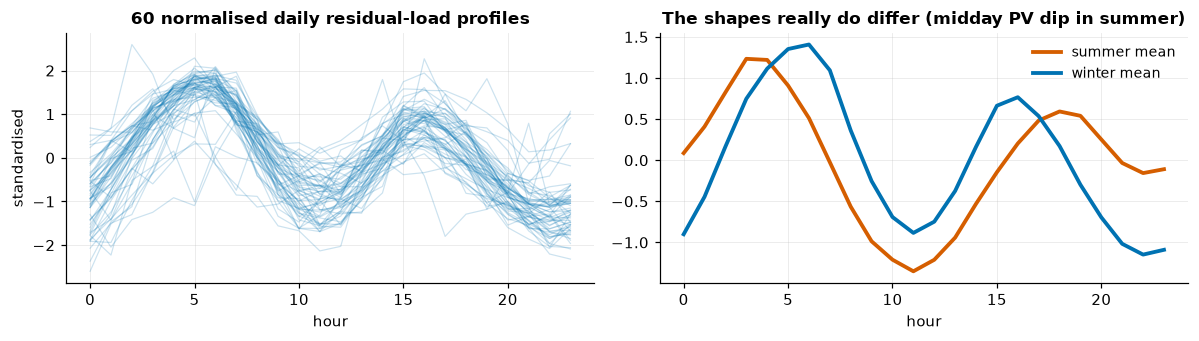

In [3]:
frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)


def daily_profiles(part: pd.DataFrame, column: str = "residual_load_mw"):
    """Reshape one split into normalised daily profiles.

    Returns ``(profiles, level, spread, dates)``. The level and spread that were
    divided out are returned rather than discarded — later sections need to know
    what the normalisation removed.
    """
    series = part[column]
    whole_days = series.groupby(series.index.date)
    complete = [d for d, g in whole_days if len(g) == 24]
    matrix = np.stack([series[series.index.date == d].to_numpy() for d in complete])
    level = matrix.mean(axis=1, keepdims=True)
    spread = matrix.std(axis=1, keepdims=True) + 1e-8
    normalised = ((matrix - level) / spread).astype(np.float32)
    return normalised[:, :, None], level.ravel(), spread.ravel(), pd.to_datetime(complete)


profiles_train, level_train, spread_train, dates_train = daily_profiles(train_raw)
profiles_valid, level_valid, spread_valid, dates_valid = daily_profiles(valid_raw)
profiles_test, level_test, spread_test, dates_test = daily_profiles(test_raw)

print(f"pretraining profiles : {profiles_train.shape}  ({dates_train[0].date()} to {dates_train[-1].date()})")
print(f"validation profiles  : {profiles_valid.shape}")
print(f"test profiles        : {profiles_test.shape}")
print("\nNo labels anywhere. These are just days.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for i in range(60):
    axes[0].plot(profiles_train[i, :, 0], color=COLORS["rnn"], alpha=0.2, lw=0.8)
axes[0].set_title("60 normalised daily residual-load profiles")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("standardised")
summer = dates_train.month.isin([6, 7, 8])
winter = dates_train.month.isin([12, 1, 2])
axes[1].plot(profiles_train[summer, :, 0].mean(axis=0), color=COLORS["transformer"],
             lw=2.5, label="summer mean")
axes[1].plot(profiles_train[winter, :, 0].mean(axis=0), color=COLORS["rnn"],
             lw=2.5, label="winter mean")
axes[1].set_title("The shapes really do differ (midday PV dip in summer)")
axes[1].set_xlabel("hour")
axes[1].legend()
fig.tight_layout()
plt.show()

## 6. From scratch: a plain autoencoder, and why it is not enough

plain autoencoder: 4,256 parameters, validation MSE 0.0425


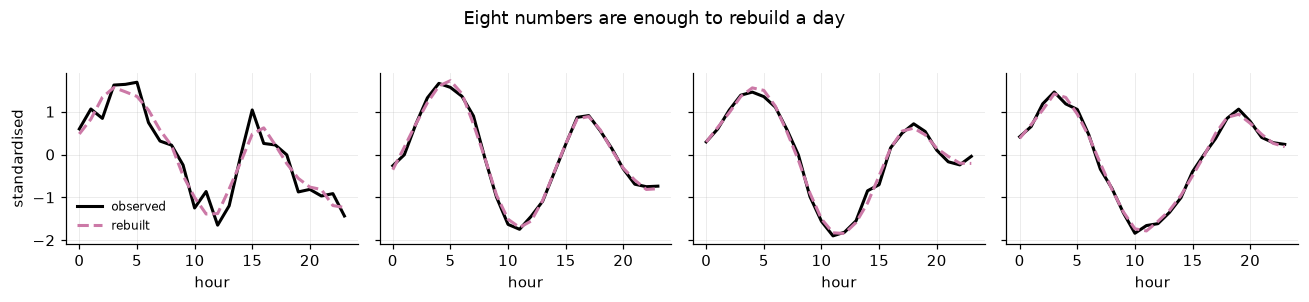

A 24-dimensional day compresses to 8 numbers with little loss — daily profiles
live on a low-dimensional manifold, and that is why this works at all.

But reconstruction is a weak objective: widen the bottleneck and the model can
simply learn to copy. Next we remove that option.


In [4]:
set_seed()
LATENT = 8


class PlainAutoencoder(nn.Module):
    """Compress 24 numbers to ``LATENT`` and expand them back."""

    def __init__(self, latent: int = LATENT) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(), nn.Linear(24, 64), nn.GELU(), nn.Linear(64, latent)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 64), nn.GELU(), nn.Linear(64, 24), nn.Unflatten(1, (24, 1))
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


plain = PlainAutoencoder()
plain_history = train_model(
    plain,
    make_loader(profiles_train, profiles_train, batch_size=32, shuffle=True),
    make_loader(profiles_valid, profiles_valid, batch_size=128),
    loss_fn=nn.MSELoss(),
    config=TrainConfig(epochs=scaled(full=60, fast=4), learning_rate=2e-3, patience=12,
                       verbose=False),
)
print(f"plain autoencoder: {count_parameters(plain):,} parameters, "
      f"validation MSE {plain_history.best_val_loss:.4f}")

with torch.no_grad():
    reconstruction = plain(torch.tensor(profiles_valid)).numpy()

fig, axes = plt.subplots(1, 4, figsize=(12, 2.6), sharey=True)
for ax, i in zip(axes, [3, 50, 120, 200], strict=True):
    ax.plot(profiles_valid[i, :, 0], color=COLORS["truth"], lw=2, label="observed")
    ax.plot(reconstruction[i, :, 0], color=COLORS["foundation"], lw=2, ls="--", label="rebuilt")
    ax.set_xlabel("hour")
axes[0].set_ylabel("standardised")
axes[0].legend(fontsize=8)
fig.suptitle("Eight numbers are enough to rebuild a day", y=1.04)
fig.tight_layout()
plt.show()

print("A 24-dimensional day compresses to 8 numbers with little loss — daily profiles")
print("live on a low-dimensional manifold, and that is why this works at all.")
print("\nBut reconstruction is a weak objective: widen the bottleneck and the model can")
print("simply learn to copy. Next we remove that option.")

## 7. Masked modelling — BERT's objective, on load profiles

Hide part of the day, rebuild it from the rest, and **score only the hidden
part**. Scoring the visible part too would reward copying.

Two masking strategies, and the difference matters:

- **random** — scatter hidden hours through the day. Easy: neighbours
  interpolate.
- **block** — hide a contiguous stretch. Hard, and it is the realistic case,
  because a communication outage removes consecutive samples.

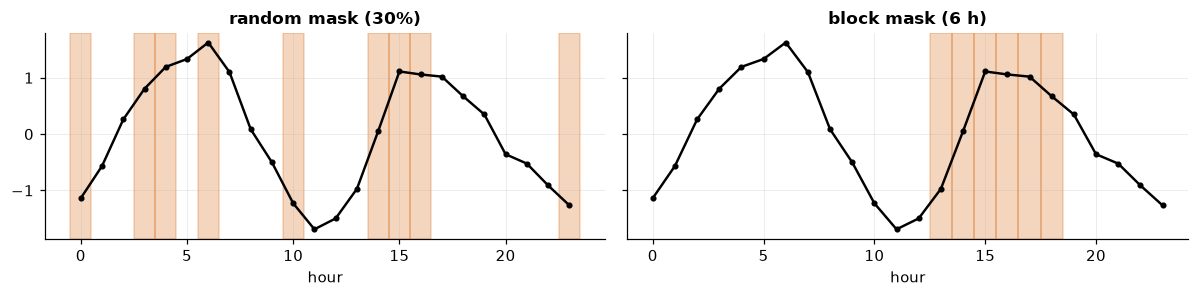

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), sharey=True)
set_seed()
example = profiles_train[7, :, 0]
for ax, (label, mask) in zip(
    axes,
    [("random mask (30%)", random_mask((1, 24), ratio=0.3)[0].numpy()),
     ("block mask (6 h)", block_mask((1, 24), block=6)[0].numpy())],
    strict=True,
):
    ax.plot(example, color=COLORS["truth"], marker="o", ms=3)
    for hour in np.where(mask)[0]:
        ax.axvspan(hour - 0.5, hour + 0.5, color=COLORS["transformer"], alpha=0.25)
    ax.set_title(label)
    ax.set_xlabel("hour")
fig.tight_layout()
plt.show()

/tmp/ipykernel_662499/1018135461.py:34: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  epoch_loss += float(loss) * len(batch)


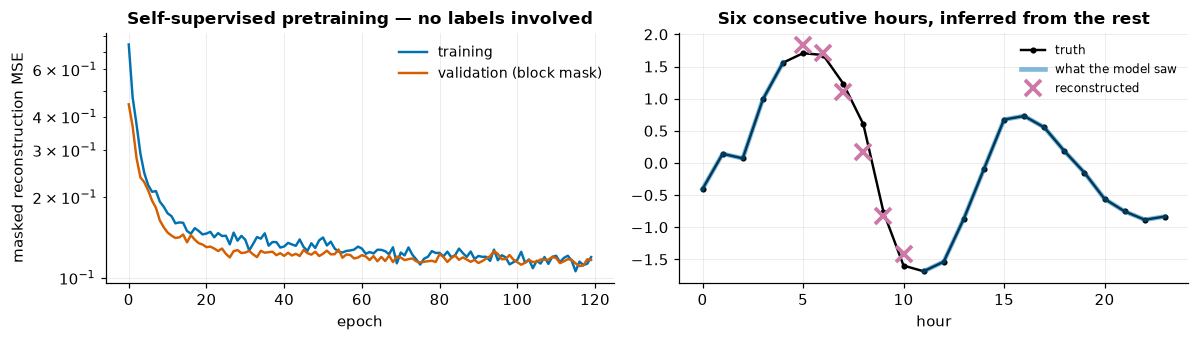

encoder parameters: 9,384
latent dimension  : 8


In [6]:
def pretrain_masked(mask_kind: str = "mixed", epochs: int | None = None) -> MaskedProfileAutoencoder:
    """Self-supervised pretraining. No labels are used anywhere in this function."""
    set_seed()
    model = MaskedProfileAutoencoder(length=24, n_channels=1, latent_dim=LATENT,
                                     hidden_channels=32)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
    generator = torch.Generator().manual_seed(0)
    inputs = torch.tensor(profiles_train)
    validation = torch.tensor(profiles_valid)
    n_epochs = epochs if epochs is not None else scaled(full=120, fast=6)
    curve = []

    for epoch in range(n_epochs):
        model.train()
        order = torch.randperm(len(inputs), generator=generator)
        epoch_loss = 0.0
        for start in range(0, len(order), 64):
            batch = inputs[order[start : start + 64]]
            if mask_kind == "random":
                mask = random_mask((len(batch), 24), ratio=0.3, generator=generator)
            elif mask_kind == "block":
                mask = block_mask((len(batch), 24), block=6, generator=generator)
            else:  # mixed: half of each, which is what most real recipes do
                half = len(batch) // 2
                mask = torch.cat([
                    random_mask((half, 24), ratio=0.3, generator=generator),
                    block_mask((len(batch) - half, 24), block=6, generator=generator),
                ])
            prediction = model(batch, mask=mask)
            loss = masked_reconstruction_loss(prediction, batch, mask)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss) * len(batch)

        model.eval()
        with torch.no_grad():
            val_mask = block_mask((len(validation), 24), block=6,
                                  generator=torch.Generator().manual_seed(1))
            val_loss = float(masked_reconstruction_loss(
                model(validation, mask=val_mask), validation, val_mask))
        curve.append((epoch_loss / len(inputs), val_loss))
    model.pretraining_curve = curve
    return model


encoder_model = pretrain_masked("mixed")
curve = np.array(encoder_model.pretraining_curve)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].semilogy(curve[:, 0], label="training", color=COLORS["rnn"])
axes[0].semilogy(curve[:, 1], label="validation (block mask)", color=COLORS["transformer"])
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("masked reconstruction MSE")
axes[0].set_title("Self-supervised pretraining — no labels involved")
axes[0].legend()

set_seed()
demo_mask = block_mask((1, 24), block=6, generator=torch.Generator().manual_seed(4))
demo_input = torch.tensor(profiles_valid[11:12])
with torch.no_grad():
    filled = encoder_model(demo_input, mask=demo_mask).numpy()[0, :, 0]
axes[1].plot(profiles_valid[11, :, 0], color=COLORS["truth"], marker="o", ms=3, label="truth")
visible = profiles_valid[11, :, 0].copy()
visible[demo_mask[0].numpy()] = np.nan
axes[1].plot(visible, color=COLORS["rnn"], lw=3, alpha=0.5, label="what the model saw")
axes[1].plot(np.where(demo_mask[0].numpy())[0], filled[demo_mask[0].numpy()], "x",
             color=COLORS["foundation"], ms=10, mew=2.5, label="reconstructed")
axes[1].set_xlabel("hour")
axes[1].set_title("Six consecutive hours, inferred from the rest")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"encoder parameters: {count_parameters(encoder_model.encoder):,}")
print(f"latent dimension  : {LATENT}")

## 8. Look at the latent space

The encoder has never been told about seasons, weekdays or PV. If it has
learned something real, those factors will show up anyway.

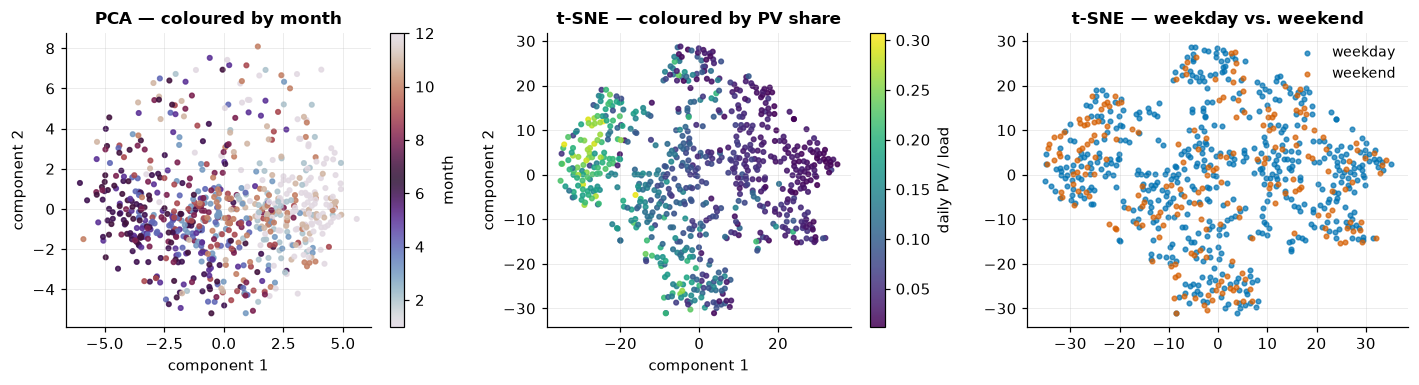

First two principal components carry 74.6% of the latent variance.


In [7]:
with torch.no_grad():
    embeddings_train = encoder_model.embed(torch.tensor(profiles_train)).numpy()
    embeddings_test = encoder_model.embed(torch.tensor(profiles_test)).numpy()

# Colour by quantities the encoder never saw.
pv_share_train = np.array([
    frame.loc[frame.index.date == d.date(), "pv_mw"].sum()
    / max(frame.loc[frame.index.date == d.date(), "load_mw"].sum(), 1e-9)
    for d in dates_train
])
is_weekend_train = dates_train.dayofweek.to_numpy() >= 5

set_seed()
coords_pca = PCA(n_components=2).fit_transform(embeddings_train)
coords_tsne = TSNE(n_components=2, perplexity=30, random_state=0,
                   init="pca").fit_transform(embeddings_train)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
plot_embedding(coords_pca, dates_train.month.to_numpy(), title="PCA — coloured by month",
               label="month", cmap="twilight", ax=axes[0])
plot_embedding(coords_tsne, pv_share_train, title="t-SNE — coloured by PV share",
               label="daily PV / load", cmap="viridis", ax=axes[1])
axes[2].scatter(coords_tsne[~is_weekend_train, 0], coords_tsne[~is_weekend_train, 1],
                s=9, color=COLORS["rnn"], label="weekday", alpha=0.7)
axes[2].scatter(coords_tsne[is_weekend_train, 0], coords_tsne[is_weekend_train, 1],
                s=9, color=COLORS["transformer"], label="weekend", alpha=0.7)
axes[2].set_title("t-SNE — weekday vs. weekend")
axes[2].legend()
fig.tight_layout()
plt.show()

explained = PCA(n_components=LATENT).fit(embeddings_train).explained_variance_ratio_
print(f"First two principal components carry {explained[:2].sum():.1%} of the latent variance.")

### How much of a factor is *linearly* readable?

The strict test of a representation: can a **linear** model recover a factor
from it? If yes, the encoder has disentangled that factor rather than merely
storing the input.

In [8]:
def linear_readout(features: np.ndarray, target: np.ndarray, name: str,
                   seed: int = 0) -> float:
    """R^2 of a ridge regression from the representation to a factor.

    A *random* split is correct here, unlike everywhere else in this course.
    The question being asked is not "does this generalise forward in time" but
    "is this factor linearly encoded in the representation at all" — a probe, not
    a forecast. A chronological split would additionally require the probe to
    extrapolate to unseen parts of the year and would confound the two
    questions.
    """
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(features))
    n_fit = int(0.7 * len(features))
    fit, held = order[:n_fit], order[n_fit:]
    model = Ridge(alpha=1.0).fit(features[fit], target[fit])
    score = r2(target[held], model.predict(features[held]))
    print(f"  {name:34s} R2 = {score:6.3f}")
    return score


daily_temperature = frame.groupby(frame.index.date).temperature_c.mean()
FACTORS = {
    "daily PV share": pv_share_train,
    "mean temperature that day": np.array([daily_temperature[d.date()] for d in dates_train]),
    "days from midsummer": np.abs(dates_train.dayofyear.to_numpy() - 172.0),
    "is it a weekend?": is_weekend_train.astype(float),
}

print("Linear readout from the 8-dimensional embedding:")
embedding_scores = {name: linear_readout(embeddings_train, values, name)
                    for name, values in FACTORS.items()}
print("\nSame readout from the raw 24 values, for reference:")
raw_train = profiles_train[:, :, 0]
raw_scores = {name: linear_readout(raw_train, values, name) for name, values in FACTORS.items()}
print("\nAnd a deliberately ambiguous encoding of the same seasonal information:")
linear_readout(embeddings_train, np.sin(2 * np.pi * dates_train.dayofyear / 365.25),
               "sin(day of year)")

Linear readout from the 8-dimensional embedding:
  daily PV share                     R2 =  0.713
  mean temperature that day          R2 =  0.439
  days from midsummer                R2 =  0.654
  is it a weekend?                   R2 = -0.063

Same readout from the raw 24 values, for reference:
  daily PV share                     R2 =  0.706
  mean temperature that day          R2 =  0.406
  days from midsummer                R2 =  0.661
  is it a weekend?                   R2 = -0.053

And a deliberately ambiguous encoding of the same seasonal information:
  sin(day of year)                   R2 =  0.008


0.007676204571306133

Read the table honestly: **some factors are linearly encoded and some are not.**

*PV share, temperature and distance from midsummer* come out clearly. All
three are essentially the same physical fact — how much sun there was — and it
changes the *shape* of a day dramatically. The masked-reconstruction objective
could not fill in a missing midday without representing it.

*Weekend versus weekday* does not. A weekend changes the level of a day much
more than its shape, and we normalised the level away before the encoder ever
saw the data. Note that the t-SNE plot above shows weekends *somewhat*
grouped: that is exactly the trap. Visible clustering in a non-linear 2-D
projection is far weaker evidence than linear decodability, and the two
disagree here.

*sin(day of year)* fails for a different and instructive reason: it is an
ambiguous target, not an unrepresented one. Two dates either side of the
solstice share a sine value while having different weather and different
profiles, so no function of the profile can predict it. A failed probe can
mean "the representation lacks this" or "your target was badly coded", and
telling those apart is your job, not the model's.

This is the central discipline of representation learning. A representation
encodes what its pretraining objective needed, and nothing else is guaranteed.

In [9]:
print("Embedding vs. raw input, by factor:")
for name in FACTORS:
    print(f"  {name:34s} embedding {embedding_scores[name]:6.3f}   raw {raw_scores[name]:6.3f}")
print("\nThe raw profile contains all the information — it is the input, after all. What")
print("matters is that 8 numbers do about as well as 24: the encoder compressed the")
print("input threefold without losing the factors that survive its objective. That")
print("compression is what makes the representation cheap to reuse, as measured next.")

Embedding vs. raw input, by factor:
  daily PV share                     embedding  0.713   raw  0.706
  mean temperature that day          embedding  0.439   raw  0.406
  days from midsummer                embedding  0.654   raw  0.661
  is it a weekend?                   embedding -0.063   raw -0.053

The raw profile contains all the information — it is the input, after all. What
matters is that 8 numbers do about as well as 24: the encoder compressed the
input threefold without losing the factors that survive its objective. That
compression is what makes the representation cheap to reuse, as measured next.


## 9. The Word2Vec intuition: similarity becomes geometry

Word2Vec's insight was not the architecture but the consequence: after
training on a throwaway prediction task, *distance in the latent space became
meaningful*. Words used in similar contexts ended up near each other, without
anybody defining "similar".

Our encoder was trained on a throwaway task too (fill in the missing hours).
So: given a day, what are its nearest neighbours in latent space?

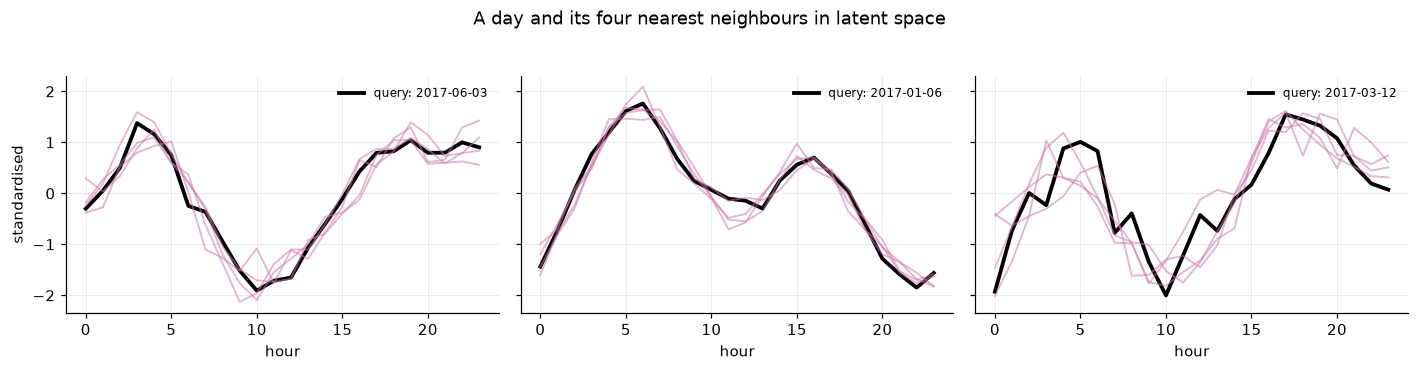

query 2017-06-03 (PV share 0.31): 100% of neighbours are within one month, mean PV share 0.20
query 2017-01-06 (PV share 0.01): 0% of neighbours are within one month, mean PV share 0.02
query 2017-03-12 (PV share 0.07): 25% of neighbours are within one month, mean PV share 0.12

Nobody defined 'similar day'. It fell out of an objective about missing hours.
This is the same phenomenon as Word2Vec's famous analogies, and it is the reason
embeddings are useful for retrieval — which is what tutorial 08's RAG system does
with text instead of days.


In [10]:
def nearest_days(query_index: int, k: int = 4) -> np.ndarray:
    """Indices of the k most similar training days, by cosine similarity."""
    normed = embeddings_train / (np.linalg.norm(embeddings_train, axis=1, keepdims=True) + 1e-9)
    similarity = normed @ normed[query_index]
    similarity[query_index] = -np.inf
    return np.argsort(similarity)[-k:][::-1]


fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
queries = [
    int(np.argmax(pv_share_train)),                                   # the sunniest day
    int(np.argmin(pv_share_train)),                                   # the dullest day
    int(np.where(is_weekend_train)[0][20]),                           # a weekend
]
for ax, query in zip(axes, queries, strict=True):
    ax.plot(profiles_train[query, :, 0], color=COLORS["truth"], lw=2.5,
            label=f"query: {dates_train[query].date()}")
    for neighbour in nearest_days(query):
        ax.plot(profiles_train[neighbour, :, 0], color=COLORS["foundation"], alpha=0.55, lw=1.2)
    ax.set_xlabel("hour")
    ax.legend(fontsize=8)
axes[0].set_ylabel("standardised")
fig.suptitle("A day and its four nearest neighbours in latent space", y=1.04)
fig.tight_layout()
plt.show()

for query in queries:
    neighbours = nearest_days(query)
    same_season = np.mean(np.abs(dates_train[neighbours].month - dates_train[query].month) <= 1)
    print(f"query {dates_train[query].date()} (PV share {pv_share_train[query]:.2f}): "
          f"{same_season:.0%} of neighbours are within one month, "
          f"mean PV share {pv_share_train[neighbours].mean():.2f}")

print("\nNobody defined 'similar day'. It fell out of an objective about missing hours.")
print("This is the same phenomenon as Word2Vec's famous analogies, and it is the reason")
print("embeddings are useful for retrieval — which is what tutorial 08's RAG system does")
print("with text instead of days.")

## 10. Contrastive learning

The third recipe. Instead of reconstructing, make two augmented *views* of the
same day agree, and disagree with other days.

The augmentations **are** the science. They encode what you believe should not
change a day's identity. For load profiles, adding noise or rescaling is safe;
reversing time is not, because a reversed day is a physically different day.

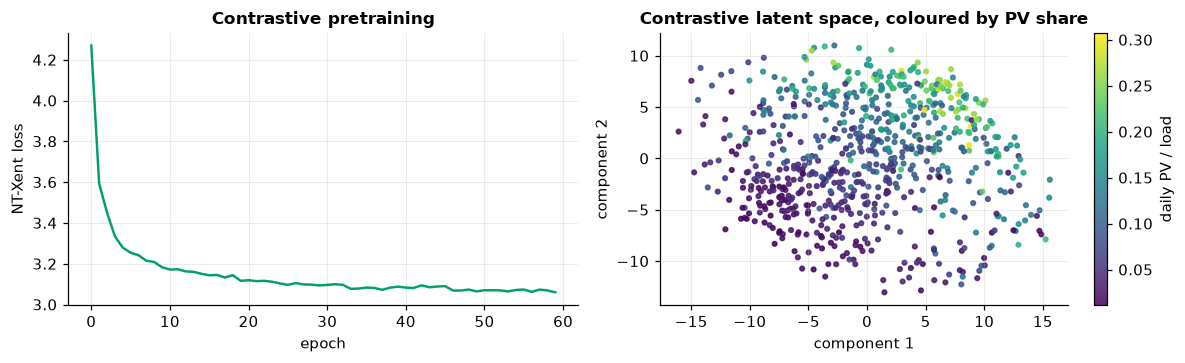

Linear readout from the contrastive embedding:
  daily PV share                     R2 =  0.725
  mean temperature that day          R2 =  0.418
  days from midsummer                R2 =  0.649
  is it a weekend?                   R2 = -0.041

A different objective produces a different — not automatically better —
representation. Which one wins depends on the downstream task, and the only
way to find out is to measure it.


In [11]:
def augment(batch: torch.Tensor, generator: torch.Generator) -> torch.Tensor:
    """Two safe augmentations: amplitude jitter and small additive noise."""
    scale = 1.0 + 0.1 * torch.randn(len(batch), 1, 1, generator=generator)
    noise = 0.05 * torch.randn(batch.shape, generator=generator)
    return batch * scale + noise


set_seed()
contrastive_encoder = ProfileEncoder(length=24, n_channels=1, latent_dim=LATENT,
                                     hidden_channels=32)
projection = nn.Sequential(nn.Linear(LATENT, 32), nn.GELU(), nn.Linear(32, 16))
optimizer = torch.optim.AdamW(
    list(contrastive_encoder.parameters()) + list(projection.parameters()), lr=2e-3
)
generator = torch.Generator().manual_seed(0)
inputs = torch.tensor(profiles_train)
contrastive_curve = []

for epoch in range(scaled(full=60, fast=4)):
    order = torch.randperm(len(inputs), generator=generator)
    total = 0.0
    for start in range(0, len(order) - 63, 64):
        batch = inputs[order[start : start + 64]]
        z1 = projection(contrastive_encoder(augment(batch, generator)))
        z2 = projection(contrastive_encoder(augment(batch, generator)))
        loss = nt_xent_loss(z1, z2, temperature=0.5)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += float(loss)
    contrastive_curve.append(total / max(len(order) // 64, 1))

with torch.no_grad():
    contrastive_embeddings = contrastive_encoder(inputs).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(contrastive_curve, color=COLORS["tree"])
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("NT-Xent loss")
axes[0].set_title("Contrastive pretraining")
plot_embedding(PCA(n_components=2).fit_transform(contrastive_embeddings), pv_share_train,
               title="Contrastive latent space, coloured by PV share",
               label="daily PV / load", cmap="viridis", ax=axes[1])
fig.tight_layout()
plt.show()

print("Linear readout from the contrastive embedding:")
for _name, _values in FACTORS.items():
    linear_readout(contrastive_embeddings, _values, _name)
print("\nA different objective produces a different — not automatically better —")
print("representation. Which one wins depends on the downstream task, and the only")
print("way to find out is to measure it.")

## 11. The experiment that matters: label efficiency

### The task

**Estimate the day's PV share (PV energy / load energy) from the residual-load
profile alone.**

This is a real power-system problem. Distribution operators routinely have
feeder measurements but no metering of behind-the-meter PV, and estimating the
hidden solar generation from the net-load shape is an active research question.
The label — actual PV energy — requires separate instrumentation, so it is
genuinely scarce, while unlabelled net-load profiles are abundant.

### The comparison

With $N$ labelled days, for $N$ from 10 to a full year:

1. **Ridge on the raw 24 values** — the classical baseline, no pretraining.
2. **Linear probe on the frozen pretrained encoder** — only 9 parameters
   trained.
3. **The same encoder architecture trained from scratch, end to end** — the
   supervised-only control.
4. **Fine-tuning the pretrained encoder** — pretrained initialisation, all
   weights updated.

All four are evaluated on the *same* held-out test year.

In [12]:
def pv_share(dates: pd.DatetimeIndex) -> np.ndarray:
    daily = frame.groupby(frame.index.date)[["pv_mw", "load_mw"]].sum()
    return np.array([
        daily.loc[d.date(), "pv_mw"] / max(daily.loc[d.date(), "load_mw"], 1e-9) for d in dates
    ])


y_pool = pv_share(dates_valid)      # labelled pool: the validation year
y_test = pv_share(dates_test)       # evaluation: the test year
X_pool, X_test = profiles_valid, profiles_test

print(f"labelled pool {len(y_pool)} days | test {len(y_test)} days")
print(f"PV share ranges {y_test.min():.3f} to {y_test.max():.3f}")
print("\nNote where each split comes from: the encoder was pretrained ONLY on the")
print("training years, so the labelled pool and the test year are both unseen by it.")

labelled pool 365 days | test 366 days
PV share ranges 0.012 to 0.284

Note where each split comes from: the encoder was pretrained ONLY on the
training years, so the labelled pool and the test year are both unseen by it.


In [13]:
def run_supervised(n_labels: int, mode: str, seed: int = 0) -> float:
    """Train one variant on ``n_labels`` days and return test MAE."""
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(y_pool), size=n_labels, replace=False)
    x_small = X_pool[chosen]
    y_small = y_pool[chosen].astype(np.float32).reshape(-1, 1)

    if mode == "ridge_raw":
        model = Ridge(alpha=1.0).fit(x_small[:, :, 0], y_small.ravel())
        return mae(y_test, model.predict(X_test[:, :, 0]))

    set_seed(seed)
    if mode == "probe":
        with torch.no_grad():
            features = encoder_model.embed(torch.tensor(x_small)).numpy()
            test_features = encoder_model.embed(torch.tensor(X_test)).numpy()
        model = Ridge(alpha=1.0).fit(features, y_small.ravel())
        return mae(y_test, model.predict(test_features))

    # End-to-end variants: same architecture, different starting weights.
    # They get a validation split carved out of their own label budget so that
    # early stopping is available to them. Without it the comparison would be
    # rigged: the probe is a closed-form ridge fit that cannot overfit its way
    # past the optimum, while an unregularised network trained for a fixed
    # number of epochs certainly can.
    encoder = ProfileEncoder(length=24, n_channels=1, latent_dim=LATENT, hidden_channels=32)
    if mode == "finetune":
        encoder.load_state_dict(encoder_model.encoder.state_dict())
    head = nn.Linear(LATENT, 1)
    network = nn.Sequential(encoder, head)
    n_inner_valid = max(2, n_labels // 4)
    train_model(
        network,
        make_loader(x_small[n_inner_valid:], y_small[n_inner_valid:],
                    batch_size=min(16, max(n_labels - n_inner_valid, 1)), shuffle=True, seed=seed),
        make_loader(x_small[:n_inner_valid], y_small[:n_inner_valid], batch_size=64),
        loss_fn=nn.MSELoss(),
        config=TrainConfig(epochs=scaled(full=150, fast=20), learning_rate=3e-3,
                           patience=25, verbose=False),
    )
    network.eval()
    with torch.no_grad():
        prediction = network(torch.tensor(X_test)).numpy().ravel()
    return mae(y_test, prediction)


LABEL_BUDGETS = [10, 20, 50, 100, 200, len(y_pool)] if not fast_mode() else [10, 50, len(y_pool)]
N_REPEATS = scaled(full=3, fast=1)
MODES = {
    "Ridge on raw 24 values": "ridge_raw",
    "Frozen encoder + linear probe": "probe",
    "Same architecture, from scratch": "scratch",
    "Pretrained encoder, fine-tuned": "finetune",
}

records = []
for budget in LABEL_BUDGETS:
    for label, mode in MODES.items():
        scores = [run_supervised(budget, mode, seed=s) for s in range(N_REPEATS)]
        records.append({"n_labels": budget, "method": label,
                        "MAE": float(np.mean(scores)), "std": float(np.std(scores))})
    print(f"  {budget:4d} labels done")

efficiency = pd.DataFrame(records)
pivot = efficiency.pivot(index="n_labels", columns="method", values="MAE")
display(pivot.round(4))

    10 labels done


    20 labels done


    50 labels done


   100 labels done


   200 labels done


   365 labels done


method,Frozen encoder + linear probe,"Pretrained encoder, fine-tuned",Ridge on raw 24 values,"Same architecture, from scratch"
n_labels,,,,
10,0.0364,0.1801,0.0355,0.0385
20,0.0375,0.1170,0.0381,0.0363
50,0.0339,0.0572,0.0339,0.0378
100,0.0316,0.0496,0.0348,0.0328
200,0.0305,0.0390,0.0319,0.0337
365,0.0297,0.0363,0.0305,0.0305


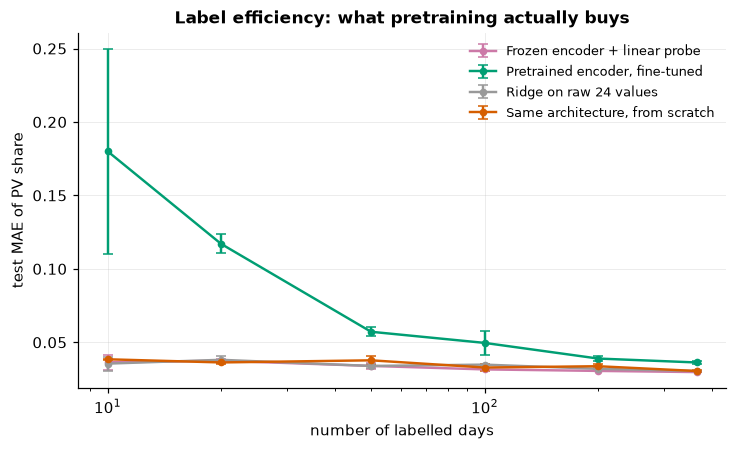

In [14]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
palette = {
    "Ridge on raw 24 values": COLORS["baseline"],
    "Frozen encoder + linear probe": COLORS["foundation"],
    "Same architecture, from scratch": COLORS["transformer"],
    "Pretrained encoder, fine-tuned": COLORS["tree"],
}
for method in pivot.columns:
    subset = efficiency[efficiency.method == method]
    ax.errorbar(subset.n_labels, subset.MAE, yerr=subset["std"], marker="o", ms=4,
                capsize=3, label=method, color=palette[method])
ax.set_xscale("log")
ax.set_xlabel("number of labelled days")
ax.set_ylabel("test MAE of PV share")
ax.set_title("Label efficiency: what pretraining actually buys")
ax.legend(fontsize=8.5)
plt.show()

In [15]:
smallest = pivot.index.min()
largest = pivot.index.max()
probe_col, scratch_col = "Frozen encoder + linear probe", "Same architecture, from scratch"
for budget in (smallest, largest):
    probe_mae = pivot.loc[budget, probe_col]
    scratch_mae = pivot.loc[budget, scratch_col]
    advantage = 1 - probe_mae / scratch_mae
    print(f"At {budget:>4} labels: probe {probe_mae:.4f}  vs. from scratch {scratch_mae:.4f}  "
          f"-> the probe's MAE is {abs(advantage):.0%} "
          f"{'lower' if advantage > 0 else 'higher'}")
print(f"\nBest method at {smallest} labels : {pivot.loc[smallest].idxmin()}")
print(f"Best method at {largest} labels: {pivot.loc[largest].idxmin()}")
print(f"\nRidge on the raw 24 values, for scale: "
      f"{pivot.loc[smallest, 'Ridge on raw 24 values']:.4f} -> "
      f"{pivot.loc[largest, 'Ridge on raw 24 values']:.4f}")

At   10 labels: probe 0.0364  vs. from scratch 0.0385  -> the probe's MAE is 5% lower
At  365 labels: probe 0.0297  vs. from scratch 0.0305  -> the probe's MAE is 2% lower

Best method at 10 labels : Ridge on raw 24 values
Best method at 365 labels: Frozen encoder + linear probe

Ridge on the raw 24 values, for scale: 0.0355 -> 0.0305


**This plot shows the foundation-model mechanism, and also its limits.**

Read it left to right. The frozen pretrained encoder — which has *nine*
trainable parameters in its head — matches or beats the same architecture
trained from scratch across the whole range, because the scratch model must
learn what a day looks like *and* the task from a handful of examples, while
the pretrained one already knows the first part.

But be precise about the size of the effect: it is a few percent, and a plain
ridge regression on the 24 raw numbers is right there with both of them. On an
input this small the advantage is real but modest, and anyone reporting it
should show the error bars (they are on the plot) before claiming a win.

The end-to-end variants are handicapped in a way worth naming: every epoch
they spend learning what a daily profile looks like is an epoch the probe did
not have to spend, and with a few dozen examples there is not enough signal to
learn both. As the label budget grows that gap narrows — and in problems with
thousands of labels it typically closes entirely, because with enough
supervision a model learns its own representation and does not need yours.
Our pool caps out at one year, so this notebook only shows the left-hand half
of that story.

So the honest claim is not "pretraining makes models better". It is:

> **Pretraining converts unlabelled data into label efficiency.**

Whether that is worth anything depends entirely on whether labels are the
scarce resource in your problem. In power systems they very often are —
measurements are everywhere, annotations are not.

Note also that a plain ridge regression on the 24 raw numbers is a serious
competitor throughout. Twenty-four values is not a hard input space. The
pretraining story gets much more compelling as the input gets bigger and more
structured, which is precisely the regime of tutorials 09 and 10.

## 12. Failure analysis: when pretraining does not help

Two ways to waste a pretraining budget, both measured.

In [16]:
# (a) A downstream target the preprocessing deleted — and an apparent recovery
# that is really a correlation.
absolute_level_pool = level_valid
absolute_level_test = level_test

with torch.no_grad():
    probe_pool = encoder_model.embed(torch.tensor(X_pool)).numpy()
    probe_test = encoder_model.embed(torch.tensor(X_test)).numpy()

probe_level = Ridge(alpha=1.0).fit(probe_pool, absolute_level_pool)
raw_level = Ridge(alpha=1.0).fit(X_pool[:, :, 0], absolute_level_pool)
mean_baseline = np.full_like(absolute_level_test, absolute_level_pool.mean())

print("Downstream target: the day's MEAN residual load in MW")
print("(every input was normalised to zero mean, so this quantity is not in the data)\n")
for label, prediction in [
    ("frozen encoder + probe", probe_level.predict(probe_test)),
    ("ridge on raw profile", raw_level.predict(X_test[:, :, 0])),
    ("predict the training mean", mean_baseline),
]:
    print(f"  {label:26s} MAE {mae(absolute_level_test, prediction):8,.0f} MW"
          f"   R2 {r2(absolute_level_test, prediction):6.3f}")

Downstream target: the day's MEAN residual load in MW
(every input was normalised to zero mean, so this quantity is not in the data)

  frozen encoder + probe     MAE    7,278 MW   R2  0.568
  ridge on raw profile       MAE    8,155 MW   R2  0.477
  predict the training mean  MAE   12,091 MW   R2 -0.008


This result is more interesting than the one you might have expected.

The per-day normalisation deleted the absolute level before either model saw
the data, so neither should be able to predict it — and yet the probe reaches
a clearly positive $R^2$. It is not recovering deleted information. It is
exploiting a **correlation**: shape depends on season, season depends on
level, so shape predicts level in *this* dataset.

That distinction decides whether the model survives deployment. A genuine
dependence transfers; a correlation of convenience breaks the moment the
relationship shifts — a mild winter, a new tariff, a large new industrial
connection. A model with no causal access to a quantity can still score well
on it, right up until it does not.

The practical lesson stands regardless: **your preprocessing and your
pretraining objective jointly decide which downstream tasks are honestly
available.** Check what you deleted before you go looking for it.

In [17]:
# (b) An encoder pretrained on the wrong distribution.
set_seed()
shuffled_profiles = profiles_train.copy()
rng = np.random.default_rng(0)
for i in range(len(shuffled_profiles)):
    rng.shuffle(shuffled_profiles[i, :, 0])      # destroy the temporal structure

original_train = profiles_train
try:
    globals()["profiles_train"] = shuffled_profiles
    broken_encoder = pretrain_masked("mixed", epochs=scaled(full=60, fast=4))
finally:
    globals()["profiles_train"] = original_train

with torch.no_grad():
    broken_pool = broken_encoder.embed(torch.tensor(X_pool)).numpy()
    broken_test = broken_encoder.embed(torch.tensor(X_test)).numpy()
broken_probe = Ridge(alpha=1.0).fit(broken_pool, y_pool)

good_probe = Ridge(alpha=1.0).fit(probe_pool, y_pool)
print("PV-share probe, full label budget:")
print(f"  encoder pretrained on real days     MAE {mae(y_test, good_probe.predict(probe_test)):.4f}")
print(f"  encoder pretrained on shuffled days MAE {mae(y_test, broken_probe.predict(broken_test)):.4f}")
print("\nSame architecture, same number of pretraining steps, same downstream head. The")
print("only difference is whether the pretraining data had real temporal structure.")
print("Pretraining is not a ritual that improves models; it is a way of absorbing")
print("structure that is actually present. Garbage in, garbage representation.")

PV-share probe, full label budget:
  encoder pretrained on real days     MAE 0.0297
  encoder pretrained on shuffled days MAE 0.0352

Same architecture, same number of pretraining steps, same downstream head. The
only difference is whether the pretraining data had real temporal structure.
Pretraining is not a ritual that improves models; it is a way of absorbing
structure that is actually present. Garbage in, garbage representation.


## 13. Exercises

**1 — Conceptual.** Section 11 found that a plain ridge regression on 24 raw
numbers competes with the pretrained encoder. Predict — with reasoning, before
testing — how that comparison changes if the profile is 15-minute resolution
(96 values) instead of hourly, or if it is a week (168 values) instead of a
day. What property of the input makes learned representations win, and how
does that connect to why foundation models emerged in language and vision
first?

**2 — Coding.** The masking strategy was "mixed". Pretrain three encoders —
random-only at 15%, random-only at 50%, and block-only at 12 hours — and
compare their label-efficiency curves on the PV-share task. Masked
autoencoders for images famously need a *very* high masking ratio (75%) to
learn anything abstract. Does the same hold for daily load profiles, and if
not, what is different about the two data types?

**3 — Research.** Pretrain the encoder on residual-load profiles as we did,
then evaluate the label-efficiency curve on a completely different downstream
target: next-day peak *hour* (a 24-class classification problem). Does the
representation transfer across task *types*, or only across tasks of the same
kind? Relate your finding to the claim in tutorial 09 that a foundation model
is defined by the breadth of what it can be adapted to.

## 14. Key takeaways

- **Self-supervision manufactures a supervised problem from the data's own
  structure.** Reconstruct, mask-and-predict, or contrast — all three need no
  annotations.
- **The representation, not the model, is the artefact.** After pretraining we
  threw the decoder away and kept an 8-dimensional encoder.
- **Some structure the encoder was never told about showed up anyway** —
  season and PV share were linearly readable — and some did not. Weekday was
  not, because we normalised away the level that distinguishes it. Check,
  do not assume.
- **Pretraining buys label efficiency, not accuracy.** Claim the right thing,
  and note that a ridge regression on 24 raw numbers stayed competitive
  throughout: the case for learned representations strengthens as inputs grow.
- **Your preprocessing and pretraining objective decide which downstream tasks
  are honestly available**, and a model can score well on a deleted quantity
  through correlation alone.

## 15. Further reading

- Mikolov et al., "Efficient Estimation of Word Representations in Vector
  Space", [arXiv:1301.3781](https://arxiv.org/abs/1301.3781).
- Devlin et al., "BERT", [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
  — masked language modelling.
- He et al., "Masked Autoencoders Are Scalable Vision Learners",
  [arXiv:2111.06377](https://arxiv.org/abs/2111.06377) — where the
  masking-ratio question in exercise 2 comes from.
- Chen et al., "SimCLR", [arXiv:2002.05709](https://arxiv.org/abs/2002.05709)
  — and its appendix on augmentation choice, which is the real content.
- Bengio, Courville & Vincent, "Representation Learning: A Review and New
  Perspectives", [arXiv:1206.5538](https://arxiv.org/abs/1206.5538).

---

**Next:** [Tutorial 05 — Attention](05_attention.ipynb). We have a way to
learn representations without labels; now we need an architecture that can
learn them at scale.